<a href="https://colab.research.google.com/github/lulumulum86/natural-style-transfer/blob/main/Naural_Style_Transfer_DLL_Tugas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Tugas 2 Matkul Deep Learning Lanjut**
---
# **Nama  : Lu'luah Nafisah Ulum**  
# **NIM     : 41236607**  
# **Kelas : TI-2023-KIP-C1**  
---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil di-mount.
Memulai proses Neural Style Transfer...
Content: mawar_putih.jpg
Style: blue_marble.jpg
....................................................................................................
Epoch 1/10 complete. Loss: 22162682.0000
....................................................................................................
Epoch 2/10 complete. Loss: 12511695.0000
....................................................................................................
Epoch 3/10 complete. Loss: 8641610.0000
....................................................................................................
Epoch 4/10 complete. Loss: 6603730.0000
....................................................................................................
Epoch 5/10 complete. Loss: 5417703.5000
............................................

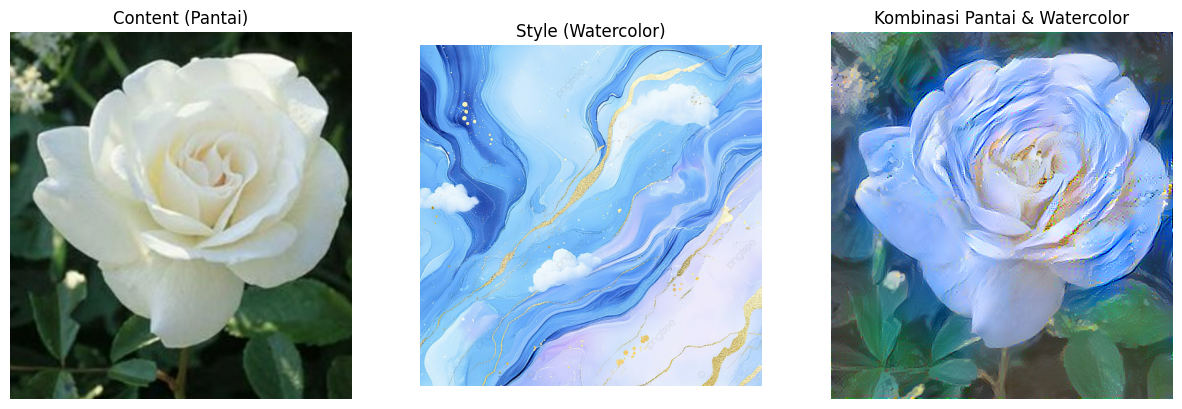

Gambar berhasil disimpan di: /content/drive/MyDrive/Colab Notebooks/Natural_Style_Transfer/hasil_kombinasi.jpg


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import vgg19
from tensorflow.keras.models import Model
import os

# -----------------------------------------------------------------------------
# 1. PERSIAPAN DAN KONFIGURASI
# -----------------------------------------------------------------------------

# Mount Google Drive (Diperlukan karena file berada di Drive)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive berhasil di-mount.")
except:
    print("Peringatan: Jalankan ini di Google Colab untuk mounting Drive otomatis.")

# Definisi Path sesuai instruksi tugas
content_path = '/content/drive/MyDrive/Colab Notebooks/Natural_Style_Transfer/mawar_putih.jpg'
style_path = '/content/drive/MyDrive/Colab Notebooks/Natural_Style_Transfer/blue_marble.jpg'

# Hyperparameters untuk Fine-Tuning Hasil
CONTENT_WEIGHT = 1e4  # Bobot untuk menjaga bentuk asli (Pantai)
STYLE_WEIGHT = 1e-2   # Bobot untuk menerapkan gaya (Watercolor)
TOTAL_VARIATION_WEIGHT = 30  # Untuk menghaluskan hasil (mengurangi noise pixel)
EPOCHS = 10
STEPS_PER_EPOCH = 100

# -----------------------------------------------------------------------------
# 2. FUNGSI UTILITAS GAMBAR
# -----------------------------------------------------------------------------

def load_and_process_img(path_to_img):
    """Memuat gambar, mengubah ukuran, dan pre-process untuk VGG19."""
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Resize gambar agar tidak terlalu berat di memori (max dimension 512px)
    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = 512 / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :] # Menambah dimensi batch
    return img

def deprocess_img(processed_img):
    """Mengembalikan gambar dari format tensor ke format gambar normal untuk ditampilkan."""
    x = processed_img.copy()
    if len(x.shape) == 4:
        x = np.squeeze(x, 0)
    assert len(x.shape) == 3

    # Karena kita tidak melakukan vgg19.preprocess_input yang mengurangi mean,
    # kita hanya perlu memastikan range pixel 0-255.
    x = np.clip(x, 0, 1) * 255
    x = np.array(x, dtype=np.uint8)
    return x

def show_results(content_image, style_image, generated_image, title="Hasil Style Transfer"):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(deprocess_img(content_image.numpy()))
    plt.title("Content (Pantai)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(deprocess_img(style_image.numpy()))
    plt.title("Style (Watercolor)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(deprocess_img(generated_image.numpy()))
    plt.title(title)
    plt.axis('off')
    plt.show()

# -----------------------------------------------------------------------------
# 3. MODEL BUILDER (VGG19)
# -----------------------------------------------------------------------------

def get_model():
    """Membangun model VGG19 yang mengembalikan output dari layer-layer spesifik."""
    vgg = vgg19.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    # Layer untuk Style (Tekstur tingkat rendah hingga tinggi)
    style_layers = ['block1_conv1',
                    'block2_conv1',
                    'block3_conv1',
                    'block4_conv1',
                    'block5_conv1']

    # Layer untuk Content (Struktur objek tingkat tinggi)
    content_layers = ['block5_conv2']

    outputs = [vgg.get_layer(name).output for name in (style_layers + content_layers)]
    model = Model([vgg.input], outputs)
    return model, style_layers, content_layers

# -----------------------------------------------------------------------------
# 4. LOSS FUNCTIONS & GRAM MATRIX
# -----------------------------------------------------------------------------

def gram_matrix(input_tensor):
    """Menghitung Gram Matrix untuk menangkap korelasi fitur (Style)."""
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result/(num_locations)

def get_feature_representations(model, content_path, style_path):
    """Mendapatkan representasi fitur dari gambar content dan style asli."""
    content_image = load_and_process_img(content_path)
    style_image = load_and_process_img(style_path)

    style_outputs = model(style_image)
    content_outputs = model(content_image)

    style_features = [style_layer[0] for style_layer in style_outputs[:5]]
    content_features = [content_layer[0] for content_layer in content_outputs[5:]]

    return style_features, content_features

def compute_loss(model, loss_weights, init_image, gram_style_features, content_features):
    style_weight, content_weight = loss_weights

    model_outputs = model(init_image)

    style_output_features = model_outputs[:5]
    content_output_features = model_outputs[5:]

    style_score = 0
    content_score = 0

    # Akumulasi Style Loss
    weight_per_style_layer = 1.0 / float(len(style_output_features))
    for target_style, comb_style in zip(gram_style_features, style_output_features):
        gram_comb = gram_matrix(comb_style)
        style_score += weight_per_style_layer * tf.reduce_mean((gram_comb - target_style)**2)

    # Akumulasi Content Loss
    weight_per_content_layer = 1.0 / float(len(content_output_features))
    for target_content, comb_content in zip(content_features, content_output_features):
        content_score += weight_per_content_layer * tf.reduce_mean((comb_content - target_content)**2)

    style_score *= style_weight
    content_score *= content_weight

    # Total Variation Loss (Optional: untuk hasil lebih mulus)
    loss = style_score + content_score + (TOTAL_VARIATION_WEIGHT * tf.image.total_variation(init_image))
    return loss

# -----------------------------------------------------------------------------
# 5. EKSEKUSI PELATIHAN (TRAINING LOOP)
# -----------------------------------------------------------------------------

def run_style_transfer():
    print("Memulai proses Neural Style Transfer...")
    print(f"Content: {os.path.basename(content_path)}")
    print(f"Style: {os.path.basename(style_path)}")

    # Inisialisasi Model
    nst_model, style_layers_names, content_layers_names = get_model()

    # Ekstraksi Fitur Target
    # Kita menggunakan preprocess vgg19 untuk ekstraksi fitur yang akurat
    content_image_pre = load_and_process_img(content_path)
    style_image_pre = load_and_process_img(style_path)

    # Preprocess khusus input VGG (scaling -1 to 1 atau centering mean) dilakukan di dalam model call secara implisit
    # Namun di sini kita menggunakan pendekatan manual scaling 0-1 dan training variable
    # Untuk fitur target, kita perlu pass forward pass

    # Mengambil fitur dari gambar statis
    outputs_style = nst_model(style_image_pre * 255.0) # VGG expect 0-255 range usually if not specific preprocess used, but here input loaded is 0-1.
    # Koreksi: VGG19 keras expect input preprocess. Kita gunakan raw 0-1 input dengan preprocessing layer opsional atau custom training.
    # Pendekatan simplified: Menggunakan vgg19.preprocess_input pada raw pixel (0-255)

    # REVISI LOADING AGAR SESUAI STANDAR VGG19 KERAS
    def vgg_process(img_tensor):
        return vgg19.preprocess_input(img_tensor * 255.0)

    # Dapatkan target gram matrix dari Style Image
    style_outputs = nst_model(vgg_process(style_image_pre))
    gram_style_features = [gram_matrix(style_layer) for style_layer in style_outputs[:len(style_layers_names)]]

    # Dapatkan target fitur dari Content Image
    content_outputs = nst_model(vgg_process(content_image_pre))
    content_features = [content_layer for content_layer in content_outputs[len(style_layers_names):]]

    # Inisialisasi gambar hasil (dimulai dari gambar content agar konvergensi lebih cepat)
    image = tf.Variable(content_image_pre)

    # Optimizer
    opt = tf.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

    @tf.function()
    def train_step(image):
        with tf.GradientTape() as tape:
            # Preprocess image variable sebelum masuk model
            preprocessed_img = vgg_process(image)
            outputs = nst_model(preprocessed_img)

            style_outputs = outputs[:len(style_layers_names)]
            content_outputs = outputs[len(style_layers_names):]

            style_score = 0
            content_score = 0

            # Hitung Style Loss
            for target_style, comb_style in zip(gram_style_features, style_outputs):
                gram_comb = gram_matrix(comb_style)
                style_score += (1.0/len(style_layers_names)) * tf.reduce_mean((gram_comb - target_style)**2)

            # Hitung Content Loss
            for target_content, comb_content in zip(content_features, content_outputs):
                content_score += (1.0/len(content_layers_names)) * tf.reduce_mean((comb_content - target_content)**2)

            style_score *= STYLE_WEIGHT
            content_score *= CONTENT_WEIGHT
            total_loss = style_score + content_score + (TOTAL_VARIATION_WEIGHT * tf.image.total_variation(image))

        grad = tape.gradient(total_loss, image)
        opt.apply_gradients([(grad, image)])
        image.assign(tf.clip_by_value(image, 0.0, 1.0)) # Jaga pixel tetap valid 0-1
        return total_loss

    # Loop Training
    import time
    start = time.time()

    for epoch in range(EPOCHS):
        for m in range(STEPS_PER_EPOCH):
            loss = train_step(image)
            print('.', end='', flush=True)

        # Perbaikan: Konversi tensor loss ke float agar format string (.4f) berfungsi
        print(f"\nEpoch {epoch+1}/{EPOCHS} complete. Loss: {float(loss):.4f}")

        # Tampilkan progress setiap epoch (opsional, bisa di-comment jika running otomatis)
        # plt.imshow(deprocess_img(image.numpy()))
        # plt.show()

    end = time.time()
    print(f"\nTotal waktu pelatihan: {end-start:.1f} detik")

    return content_image_pre, style_image_pre, image

# Jalankan Utama
if __name__ == "__main__":
    if os.path.exists(content_path) and os.path.exists(style_path):
        content, style, result = run_style_transfer()

        # Tampilkan Hasil Akhir
        show_results(content, style, result, title="Kombinasi Pantai & Watercolor")

        # Simpan Hasil
        save_path = '/content/drive/MyDrive/Colab Notebooks/Natural_Style_Transfer/hasil_kombinasi.jpg'
        tf.keras.utils.save_img(save_path, deprocess_img(result.numpy()))
        print(f"Gambar berhasil disimpan di: {save_path}")
    else:
        print("Error: File gambar tidak ditemukan. Pastikan path di Google Drive sudah benar.")